# Evaluación entre diferentes Modelos de Clasificación

Presentado por: Diego Orjuela - Alex Rodriguez - Ana Salcedo 

## 1. Librerias y configuraciones previas


In [1]:
# Tratamiento de datos
# ==============================================================================
import pandas as pd
import numpy as np


# Almacenar en caché los resultados de funciones en el disco
# ==============================================================================
import joblib
import os


# Gestion de librerias
# ==============================================================================
from importlib import reload


# Matemáticas y estadísticas
# ==============================================================================
import math

# Preprocesado y modelado
# ==============================================================================

# Preparación de datos
from sklearn.neighbors import LocalOutlierFactor

#Separar los datos entrenamiento y prueba
from sklearn.model_selection import train_test_split

#Escalar Variables
from sklearn.preprocessing import MinMaxScaler

#Evaluación del modelo
from sklearn import metrics
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve

#configuracion de hiperparámetros
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score

# Gráficos
# ==============================================================================
import matplotlib.pyplot as plt
from matplotlib import style
import seaborn as sns

# Interuactuar con os y solicitudes desde HTTP
# ==============================================================================
import os
import sys
import requests

# Configuración warnings
# ==============================================================================
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Parametros globales
# ==============================================================================

# Construimos la URL de la API de GitHub para el directorio de modelos
# El formato es: https://api.github.com/repos/{owner}/{repo}/contents/{path}
api_url = "https://api.github.com/repos/Smartdvis17/churn/contents/modelos/clasificacion"

# URL base de GitHub para el repositorio
GITHUB_BASE_URL = 'https://raw.githubusercontent.com/Smartdvis17/churn/master/'

# Nombres de los archivos requeridos
DATASET_FILE_NAME_PRUE = 'telco_Prue.csv'
DATASET_FILE_NAME_PREP = 'telco_Prep.csv'
UTILS_FILE_NAME = 'funciones.py'
SCALER_FILE_NAME = 'minmaxFull_Telco.pkl'

# Nombres de los directorios para utilidades, datasets y modelos
DATASETS_PATH = 'datasets/'
UTILS_PATH = 'utils/'
MODELS_PATH = 'modelos/'
MODELS_CLASIFICATION_PATH = os.path.join(MODELS_PATH, 'clasificacion')
MODELS_SCALER_PATH = os.path.join(MODELS_PATH, 'scaler')

# Rutas URL: usar siempre '/' para evitar rutas inválidas en Windows
DATASETS_URL_PATH = 'datasets'
UTILS_URL_PATH = 'utils'
MODELS_CLASSIFICATION_URL_PATH = 'modelos/clasificacion'
MODELS_SCALER_URL_PATH = 'modelos/scaler'

# URL completa del dataset y utils en GitHub
github_dataset_url_prue = f"{GITHUB_BASE_URL}{DATASETS_URL_PATH}/{DATASET_FILE_NAME_PRUE}"
github_dataset_url_prep = f"{GITHUB_BASE_URL}{DATASETS_URL_PATH}/{DATASET_FILE_NAME_PREP}"
github_utils_url = f"{GITHUB_BASE_URL}{UTILS_URL_PATH}/{UTILS_FILE_NAME}"
github_scaler_url = f"{GITHUB_BASE_URL}{MODELS_SCALER_URL_PATH}/{SCALER_FILE_NAME}"

# Rutas locales completas de datasets y utils
local_dataset_path_prue = os.path.join(DATASETS_PATH, DATASET_FILE_NAME_PRUE)
local_dataset_path_prep = os.path.join(DATASETS_PATH, DATASET_FILE_NAME_PREP)
local_utils_path = os.path.join(UTILS_PATH, UTILS_FILE_NAME)
local_scaler_path = os.path.join(MODELS_SCALER_PATH, SCALER_FILE_NAME)

In [3]:
## Cargar datos desde Google Drive
## ==============================================================================

#from google.colab import drive

## Montar Google Drive
#drive.mount('/gdrive')

## Establece el directorio de trabajo dentro de directorio espefíficado en Google Drive
#os.chdir("/gdrive/MyDrive/01_Academia/02_Cursos/20260401_ApredinzajeAutomáticoI_UdeA/")

## Listar archivos de directorio
##!ls

In [4]:
# Funcion local para la carga de archivos
# ==============================================================================

def download_file(url, path, description):
    '''
    Descarga un archivo desde una URL y lo guarda localmente.

    Args:
        url (str): URL del archivo
        path (str): Ruta local de destino
        description (str): Descripción del archivo
    Returns:
        None
    '''
    print(f"Descargando {description} desde: {url}")

    # Realiza una solicitud HTTP GET a la URL proporcionada
    response = requests.get(url)

    # Lanza una excepción si la descarga falla (código de estado HTTP no 200)
    response.raise_for_status()

    # Abre el archivo local en modo de escritura binaria ('wb')
    with open(path, 'wb') as f:
        # Escribe el contenido binario de la respuesta HTTP en el archivo local
        f.write(response.content)

    # Imprime un mensaje confirmando que la descarga fue exitosa y la ruta de guardado
    print(f"{description} descargado exitosamente a: {path}")

In [5]:
# Creación de directorios locales
os.makedirs(DATASETS_PATH, exist_ok=True)
os.makedirs(UTILS_PATH, exist_ok=True)
os.makedirs(MODELS_PATH, exist_ok=True)

# Crear subdirectorios específicos para modelos y escalados
os.makedirs(MODELS_CLASIFICATION_PATH, exist_ok=True)
os.makedirs(MODELS_SCALER_PATH, exist_ok=True)

# Descarga de archivos
download_file(github_dataset_url_prue, local_dataset_path_prue, "dataset")
download_file(github_dataset_url_prep, local_dataset_path_prep, "dataset")
download_file(github_utils_url, local_utils_path, "funciones")
download_file(github_scaler_url,local_scaler_path, "scaler")

Descargando dataset desde: https://raw.githubusercontent.com/Smartdvis17/churn/master/datasets/telco_Prue.csv
dataset descargado exitosamente a: datasets/telco_Prue.csv
Descargando dataset desde: https://raw.githubusercontent.com/Smartdvis17/churn/master/datasets/telco_Prep.csv
dataset descargado exitosamente a: datasets/telco_Prep.csv
Descargando funciones desde: https://raw.githubusercontent.com/Smartdvis17/churn/master/utils/funciones.py
funciones descargado exitosamente a: utils/funciones.py
Descargando scaler desde: https://raw.githubusercontent.com/Smartdvis17/churn/master/modelos/scaler/minmaxFull_Telco.pkl
scaler descargado exitosamente a: modelos/scaler\minmaxFull_Telco.pkl


In [6]:
# Obtener la lista de archivos desde la API de GitHub
# ==============================================================================

print(f"Consultando lista de modelos en: {api_url}")
response = requests.get(api_url)
response.raise_for_status()

# Filtrar solo archivos .pkl
repo_contents = response.json()
model_file_names = [file['name'] for file in repo_contents if file['name'].endswith('.pkl')]

print(f"Modelos encontrados: {model_file_names}")

# Descargar cada modelo encontrado
for model_name in model_file_names:
    github_model_url = f"{GITHUB_BASE_URL}{MODELS_CLASSIFICATION_URL_PATH}/{model_name}"
    local_model_path = os.path.join(MODELS_CLASIFICATION_PATH, model_name)
    download_file(github_model_url, local_model_path, f"modelo {model_name}")

Consultando lista de modelos en: https://api.github.com/repos/Smartdvis17/churn/contents/modelos/clasificacion
Modelos encontrados: ['DTreeC_CV.pkl', 'RForest_base_bal.pkl', 'RForest_base_unbal.pkl', 'RForest_oob.pkl', 'RForest_oob_unbal.pkl', 'RForest_oversampling.pkl', 'lr_lbfgs_base.pkl', 'lr_lbfgs_base_none.pkl', 'lr_lbfgs_opt_balanced.pkl', 'lr_lbfgs_opt_none.pkl', 'lr_lbfgs_oversampling.pkl', 'lr_liblinear_base.pkl', 'lr_liblinear_base_none.pkl', 'lr_liblinear_opt_balanced.pkl', 'lr_liblinear_opt_none.pkl', 'lr_liblinear_oversampling.pkl', 'lr_saga_base.pkl', 'lr_saga_base_none.pkl', 'lr_saga_opt_balanced.pkl', 'lr_saga_opt_none.pkl', 'lr_saga_oversampling.pkl']
Descargando modelo DTreeC_CV.pkl desde: https://raw.githubusercontent.com/Smartdvis17/churn/master/modelos/clasificacion/DTreeC_CV.pkl
modelo DTreeC_CV.pkl descargado exitosamente a: modelos/clasificacion\DTreeC_CV.pkl
Descargando modelo RForest_base_bal.pkl desde: https://raw.githubusercontent.com/Smartdvis17/churn/maste

## 2. Funciones

In [7]:
## Funciones externas
# ==============================================================================

## Añade la ruta definida en 'UTILS_PATH' al 'sys.path' para que Python pueda encontrar módulos
sys.path.append(UTILS_PATH)

## Importar Funciones externas
from utils.funciones import multiple_plot, plot_roc_curve

## 3. Carga del dataset

In [8]:
#Carga del dataset

dp=pd.read_csv(local_dataset_path_prue)
dp.shape

(705, 41)

In [9]:
dp.info()

<class 'pandas.DataFrame'>
RangeIndex: 705 entries, 0 to 704
Data columns (total 41 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Gender                             705 non-null    str    
 1   Age                                705 non-null    int64  
 2   Senior Citizen                     705 non-null    str    
 3   Married                            705 non-null    str    
 4   Number of Dependents               705 non-null    int64  
 5   Zip Code                           705 non-null    int64  
 6   Latitude                           705 non-null    float64
 7   Longitude                          705 non-null    float64
 8   Population                         705 non-null    int64  
 9   Referred a Friend                  705 non-null    str    
 10  Number of Referrals                705 non-null    int64  
 11  Tenure in Months                   705 non-null    int64  
 12  Offer

## 4. Visualización de datos

### Variables de entrada

In [10]:
#Lista de variables categóricas
catCols = dp.select_dtypes(include = ["object", 'category']).columns.tolist()

dp[catCols].head(2)

,Gender,Senior Citizen,Married,Referred a Friend,Offer,Phone Service,Multiple Lines,Internet Service,Internet Type,Online Security,...,Premium Tech Support,Streaming TV,Streaming Movies,Streaming Music,Unlimited Data,Contract,Paperless Billing,Payment Method,Customer Status,Churn Label
0,Male,Yes,No,No,Offer D,Yes,Yes,Yes,Cable,No,...,No,Yes,Yes,No,No,Month-to-Month,Yes,Bank Withdrawal,Churned,Yes
1,Male,Yes,No,No,No offer,Yes,No,Yes,Fiber Optic,No,...,No,No,No,No,Yes,Month-to-Month,Yes,Bank Withdrawal,Churned,Yes


In [11]:
#Lista de variables numéricas

numCols=dp.select_dtypes(include = ['float64','float64','int32','int64']).columns.tolist()

dp[numCols].head(2)

,Age,Number of Dependents,Zip Code,Latitude,Longitude,Population,Number of Referrals,Tenure in Months,Avg Monthly Long Distance Charges,Avg Monthly GB Download,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Satisfaction Score,Churn Score,CLTV
0,68,0,91748,33.976753,-117.897367,46342,0,13,32.68,11,106.9,1364.30,0.0,10,424.84,1799.14,1,84,2494
1,66,0,91901,32.827184,-116.703729,16486,0,8,1.78,7,74.5,606.55,0.0,0,14.24,620.79,2,80,4345


In [12]:
#Eliminar la variable de salida de la lista de variable categóricas
catCols.remove('Churn Label')

### Variable de salida

In [13]:
# Distriución de la variable de salida

dp.groupby('Churn Label')['Churn Label'].count().sort_values(ascending=False)

Churn Label
No     524
Yes    181
Name: Churn Label, dtype: int64

## 5. Transformación de datos

### Creación de variables Dummies

In [14]:
# Aplicación de la función de usuario Dummies: one-hot encoding

dp =pd.get_dummies(dp, drop_first=1)

dp.info()

<class 'pandas.DataFrame'>
RangeIndex: 705 entries, 0 to 704
Data columns (total 50 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Age                                705 non-null    int64  
 1   Number of Dependents               705 non-null    int64  
 2   Zip Code                           705 non-null    int64  
 3   Latitude                           705 non-null    float64
 4   Longitude                          705 non-null    float64
 5   Population                         705 non-null    int64  
 6   Number of Referrals                705 non-null    int64  
 7   Tenure in Months                   705 non-null    int64  
 8   Avg Monthly Long Distance Charges  705 non-null    float64
 9   Avg Monthly GB Download            705 non-null    int64  
 10  Monthly Charge                     705 non-null    float64
 11  Total Charges                      705 non-null    float64
 12  Total

### Columnas categóricas faltantes

In [15]:
#Carga del dataset

d=pd.read_csv(local_dataset_path_prep)
d.shape

(6326, 41)

In [16]:
# Aplicación de la función de usuario Dummies: one-hot encoding

d =pd.get_dummies(d, drop_first=1)

d.shape

(6326, 50)

In [17]:
# Obtener las columnas categóricas que están en el dataframe original pero no en el dataset de pruebas

missingCols = set(d.columns) - set(dp.columns)

# Agregar columnas con valores predeterminados 0
for col in missingCols:
    dp[col] = 0

In [18]:
dp

,Age,Number of Dependents,Zip Code,Latitude,Longitude,Population,Number of Referrals,Tenure in Months,Avg Monthly Long Distance Charges,Avg Monthly GB Download,...,Streaming Music_Yes,Unlimited Data_Yes,Contract_One Year,Contract_Two Year,Paperless Billing_Yes,Payment Method_Credit Card,Payment Method_Mailed Check,Customer Status_Joined,Customer Status_Stayed,Churn Label_Yes
0,68,0,91748,33.976753,-117.897367,46342,0,13,32.68,11,...,False,False,False,False,True,False,False,False,False,True
1,66,0,91901,32.827184,-116.703729,16486,0,8,1.78,7,...,False,True,False,False,True,False,False,False,False,True
2,69,0,92122,32.857230,-117.209774,34902,0,24,30.87,15,...,False,True,False,False,True,False,False,False,False,True
3,80,0,92571,33.828289,-117.201666,26357,2,27,7.02,25,...,False,True,False,False,True,False,False,False,False,True
4,68,0,92823,33.924143,-117.793870,1408,0,1,45.81,21,...,False,True,False,False,True,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
700,36,0,92124,32.827238,-117.089287,30206,0,8,37.37,16,...,False,True,False,False,True,False,False,False,True,False
701,54,0,92253,33.695532,-116.310571,23971,0,40,2.83,22,...,False,True,False,False,True,False,False,False,True,False
702,39,1,92262,33.839989,-116.659215,24924,2,12,25.33,0,...,False,False,False,False,True,False,False,False,True,False
703,57,0,92283,32.852947,-114.850784,3663,0,19,29.55,13,...,False,True,False,False,True,False,False,False,True,False


In [19]:
# Definimos las variables de entrada (X) y la variable objetivo (y)
exclude = [
    # leakage
    'Churn Score',
    'CLTV',
    'Total Revenue',
    'Customer Status_Joined',
    'Customer Status_Stayed',
    'Satisfaction Score',

    # target
    'Churn Label_Yes',

    # geo noise
    'Zip Code',
    'Latitude',
    'Longitude',
    'Population',
]

Xp = dp.drop(columns=exclude)
yp = dp['Churn Label_Yes']

vDep = Xp.columns.tolist()
print('Columnas en X después de excluir variables:', vDep)

Columnas en X después de excluir variables: ['Age', 'Number of Dependents', 'Number of Referrals', 'Tenure in Months', 'Avg Monthly Long Distance Charges', 'Avg Monthly GB Download', 'Monthly Charge', 'Total Charges', 'Total Refunds', 'Total Extra Data Charges', 'Total Long Distance Charges', 'Gender_Male', 'Senior Citizen_Yes', 'Married_Yes', 'Referred a Friend_Yes', 'Offer_Offer A', 'Offer_Offer B', 'Offer_Offer C', 'Offer_Offer D', 'Offer_Offer E', 'Phone Service_Yes', 'Multiple Lines_Yes', 'Internet Service_Yes', 'Internet Type_DSL', 'Internet Type_Fiber Optic', 'Internet Type_No internet', 'Online Security_Yes', 'Online Backup_Yes', 'Device Protection Plan_Yes', 'Premium Tech Support_Yes', 'Streaming TV_Yes', 'Streaming Movies_Yes', 'Streaming Music_Yes', 'Unlimited Data_Yes', 'Contract_One Year', 'Contract_Two Year', 'Paperless Billing_Yes', 'Payment Method_Credit Card', 'Payment Method_Mailed Check']


In [20]:
#Escalar Variables númericas

# Se establecen las variables numéricas a escalar

# Get the list of numerical columns that are actually in Xp
num_vars_to_scale = [col for col in numCols if col in Xp.columns]

print(num_vars_to_scale)

pd.set_option('display.float_format', lambda x: '%.4f' % x)

# Cargar el scaler descargado para este proyecto
scaler = joblib.load(local_scaler_path)

# Se escalan los valores del dataset entrenamiento y prueba de las columnas numéricas
Xp[num_vars_to_scale] = scaler.transform(Xp[num_vars_to_scale])

Xp[num_vars_to_scale].head(2)

['Age', 'Number of Dependents', 'Number of Referrals', 'Tenure in Months', 'Avg Monthly Long Distance Charges', 'Avg Monthly GB Download', 'Monthly Charge', 'Total Charges', 'Total Refunds', 'Total Extra Data Charges', 'Total Long Distance Charges']


,Age,Number of Dependents,Number of Referrals,Tenure in Months,Avg Monthly Long Distance Charges,Avg Monthly GB Download,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges
0,0.8033,0.0000,0.0000,0.1690,0.6537,0.1294,0.8819,0.1553,0.0000,0.0667,0.1192
1,0.7705,0.0000,0.0000,0.0986,0.0356,0.0824,0.5590,0.0678,0.0000,0.0000,0.0040


## 6. Creación del modelo

#### Creación y entrenamiento del modelo

In [21]:
# Lista para almacenar los modelos cargados
modelos_cargados = []
dr = pd.DataFrame()

# Modelos excluidos de la evaluacion final
MODELOS_EXCLUIDOS = {'DTreeC_CV.pkl'}

# Itera sobre los archivos en la ruta
for archivo_modelo in os.listdir(MODELS_CLASIFICATION_PATH):

    if archivo_modelo.endswith('.pkl') and archivo_modelo not in MODELOS_EXCLUIDOS:
        ruta_completa = os.path.join(MODELS_CLASIFICATION_PATH, archivo_modelo)

        # Carga el modelo utilizando joblib
        modelo_cargado = joblib.load(ruta_completa)

        # Recupera las características utilizadas durante el entrenamiento del modelo
        entrenamiento_features = modelo_cargado.feature_names_in_

        # Filtra y reordena las características del conjunto de datos Xp según las del modelo cargado
        Xp = Xp[entrenamiento_features]

        # Realiza predicciones
        y_pred = modelo_cargado.predict(Xp)

        # Adicionar una nueva fila
        nuevoModelo = {'model': archivo_modelo
                      , 'Descripcion': modelo_cargado
                      , 'accuracy': metrics.accuracy_score(yp, y_pred)
                      , 'recall': metrics.recall_score(yp, y_pred)
                      , 'f1_score': metrics.f1_score(yp, y_pred)
                      , 'AUC': metrics.roc_auc_score(yp, y_pred)
                      , 'support': round(dp.shape[0],0)
                     }
        dr = pd.concat([dr, pd.DataFrame([nuevoModelo])], ignore_index=True)

# Imprimir el DataFrame actualizado
dr

,model,Descripcion,accuracy,recall,f1_score,AUC,support
0,lr_lbfgs_base.pkl,"LogisticRegression(class_weight='balanced', ma...",0.8113,0.8619,0.7011,0.8279,705
1,lr_lbfgs_base_none.pkl,"LogisticRegression(max_iter=1000, random_state=0)",0.8511,0.6630,0.6957,0.7895,705
2,lr_lbfgs_opt_balanced.pkl,"LogisticRegression(C=100, class_weight='balanc...",0.8057,0.8508,0.6921,0.8205,705
3,lr_lbfgs_opt_none.pkl,"LogisticRegression(C=10, max_iter=1000, random...",0.8553,0.6740,0.7052,0.7960,705
4,lr_lbfgs_oversampling.pkl,"LogisticRegression(max_iter=1000, random_state=0)",0.8085,0.8619,0.6980,0.8260,705
5,lr_liblinear_base.pkl,"LogisticRegression(class_weight='balanced', ma...",0.8113,0.8564,0.6998,0.8261,705
6,lr_liblinear_base_none.pkl,"LogisticRegression(max_iter=1000, penalty='l1'...",0.8496,0.6630,0.6936,0.7886,705
7,lr_liblinear_opt_balanced.pkl,"LogisticRegression(C=100, class_weight='balanc...",0.8071,0.8508,0.6937,0.8214,705
8,lr_liblinear_opt_none.pkl,"LogisticRegression(C=100, max_iter=1000, penal...",0.8610,0.6796,0.7151,0.8016,705
9,lr_liblinear_oversampling.pkl,"LogisticRegression(max_iter=1000, penalty='l1'...",0.8057,0.8619,0.6949,0.8241,705


In [22]:
# Los mejores modelos ordenados por Recall (objetivo operativo del proyecto)
dr.sort_values(by='recall', ascending=False)

,model,Descripcion,accuracy,recall,f1_score,AUC,support
0,lr_lbfgs_base.pkl,"LogisticRegression(class_weight='balanced', ma...",0.8113,0.8619,0.7011,0.8279,705
4,lr_lbfgs_oversampling.pkl,"LogisticRegression(max_iter=1000, random_state=0)",0.8085,0.8619,0.6980,0.8260,705
10,lr_saga_base.pkl,"LogisticRegression(class_weight='balanced', l1...",0.8128,0.8619,0.7027,0.8288,705
14,lr_saga_oversampling.pkl,"LogisticRegression(l1_ratio=0.2, max_iter=1000...",0.8085,0.8619,0.6980,0.8260,705
9,lr_liblinear_oversampling.pkl,"LogisticRegression(max_iter=1000, penalty='l1'...",0.8057,0.8619,0.6949,0.8241,705
5,lr_liblinear_base.pkl,"LogisticRegression(class_weight='balanced', ma...",0.8113,0.8564,0.6998,0.8261,705
7,lr_liblinear_opt_balanced.pkl,"LogisticRegression(C=100, class_weight='balanc...",0.8071,0.8508,0.6937,0.8214,705
12,lr_saga_opt_balanced.pkl,"LogisticRegression(C=100, class_weight='balanc...",0.8071,0.8508,0.6937,0.8214,705
2,lr_lbfgs_opt_balanced.pkl,"LogisticRegression(C=100, class_weight='balanc...",0.8057,0.8508,0.6921,0.8205,705
19,RForest_oversampling.pkl,"(DecisionTreeClassifier(criterion='entropy', m...",0.8298,0.8343,0.7156,0.8312,705


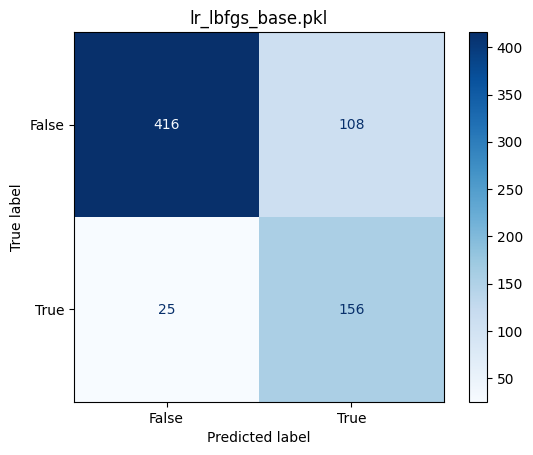

              precision    recall  f1-score   support

       False       0.94      0.79      0.86       524
        True       0.59      0.86      0.70       181

    accuracy                           0.81       705
   macro avg       0.77      0.83      0.78       705
weighted avg       0.85      0.81      0.82       705



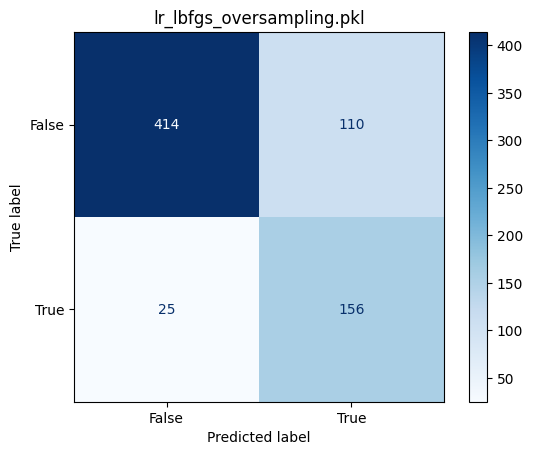

              precision    recall  f1-score   support

       False       0.94      0.79      0.86       524
        True       0.59      0.86      0.70       181

    accuracy                           0.81       705
   macro avg       0.76      0.83      0.78       705
weighted avg       0.85      0.81      0.82       705



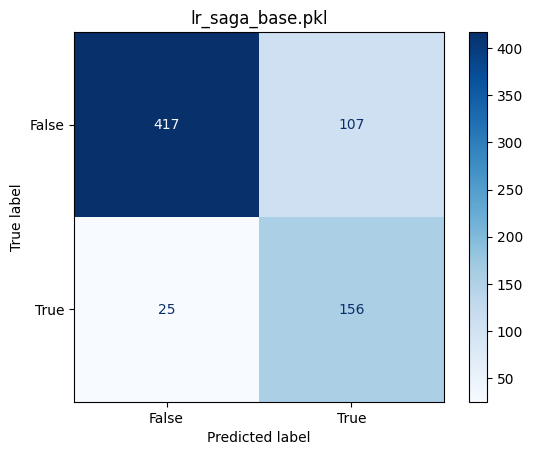

              precision    recall  f1-score   support

       False       0.94      0.80      0.86       524
        True       0.59      0.86      0.70       181

    accuracy                           0.81       705
   macro avg       0.77      0.83      0.78       705
weighted avg       0.85      0.81      0.82       705



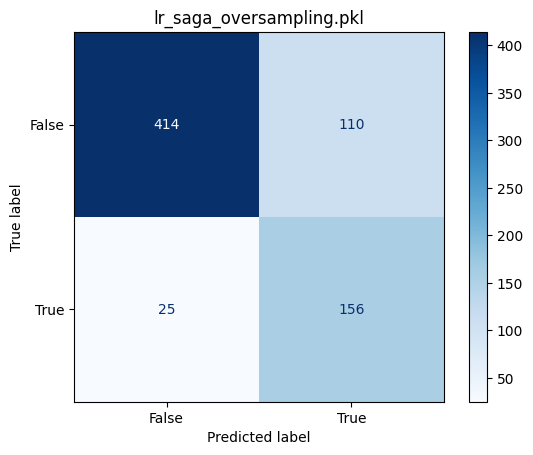

              precision    recall  f1-score   support

       False       0.94      0.79      0.86       524
        True       0.59      0.86      0.70       181

    accuracy                           0.81       705
   macro avg       0.76      0.83      0.78       705
weighted avg       0.85      0.81      0.82       705



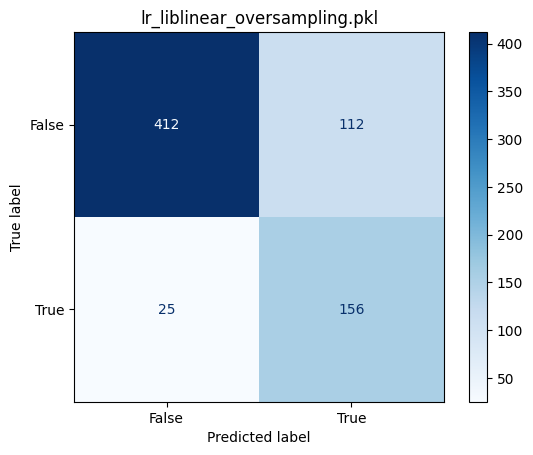

              precision    recall  f1-score   support

       False       0.94      0.79      0.86       524
        True       0.58      0.86      0.69       181

    accuracy                           0.81       705
   macro avg       0.76      0.82      0.78       705
weighted avg       0.85      0.81      0.82       705



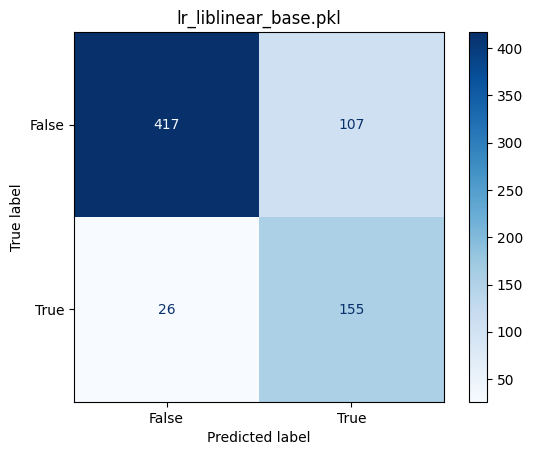

              precision    recall  f1-score   support

       False       0.94      0.80      0.86       524
        True       0.59      0.86      0.70       181

    accuracy                           0.81       705
   macro avg       0.77      0.83      0.78       705
weighted avg       0.85      0.81      0.82       705



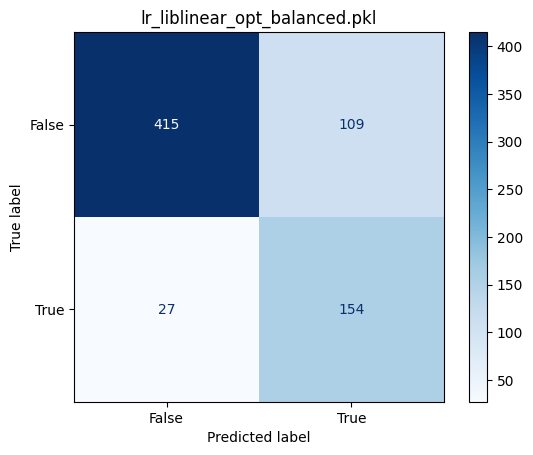

              precision    recall  f1-score   support

       False       0.94      0.79      0.86       524
        True       0.59      0.85      0.69       181

    accuracy                           0.81       705
   macro avg       0.76      0.82      0.78       705
weighted avg       0.85      0.81      0.82       705



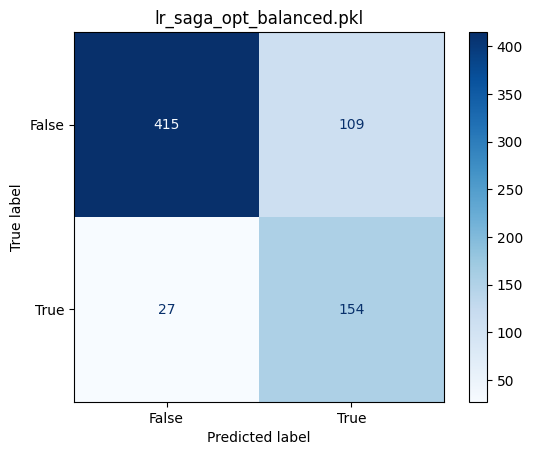

              precision    recall  f1-score   support

       False       0.94      0.79      0.86       524
        True       0.59      0.85      0.69       181

    accuracy                           0.81       705
   macro avg       0.76      0.82      0.78       705
weighted avg       0.85      0.81      0.82       705



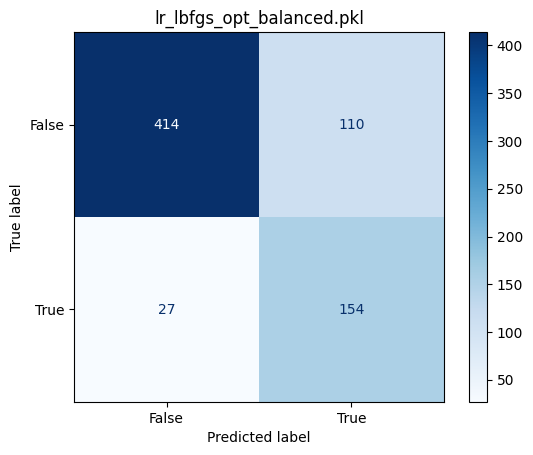

              precision    recall  f1-score   support

       False       0.94      0.79      0.86       524
        True       0.58      0.85      0.69       181

    accuracy                           0.81       705
   macro avg       0.76      0.82      0.78       705
weighted avg       0.85      0.81      0.82       705



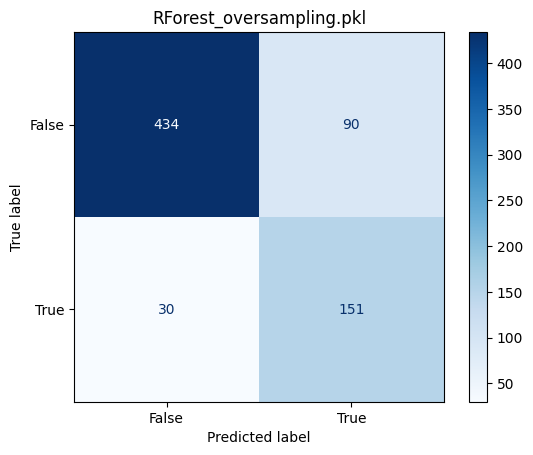

              precision    recall  f1-score   support

       False       0.94      0.83      0.88       524
        True       0.63      0.83      0.72       181

    accuracy                           0.83       705
   macro avg       0.78      0.83      0.80       705
weighted avg       0.86      0.83      0.84       705



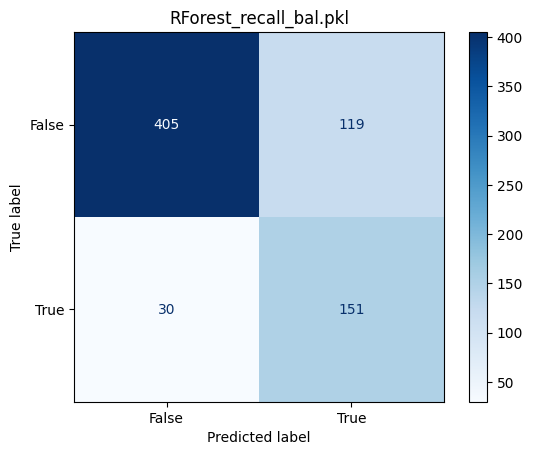

              precision    recall  f1-score   support

       False       0.93      0.77      0.84       524
        True       0.56      0.83      0.67       181

    accuracy                           0.79       705
   macro avg       0.75      0.80      0.76       705
weighted avg       0.84      0.79      0.80       705



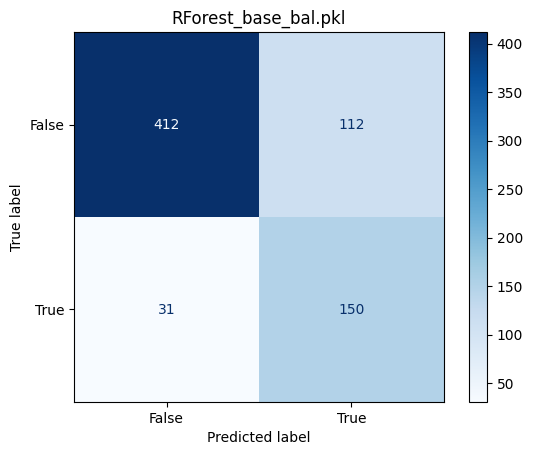

              precision    recall  f1-score   support

       False       0.93      0.79      0.85       524
        True       0.57      0.83      0.68       181

    accuracy                           0.80       705
   macro avg       0.75      0.81      0.76       705
weighted avg       0.84      0.80      0.81       705



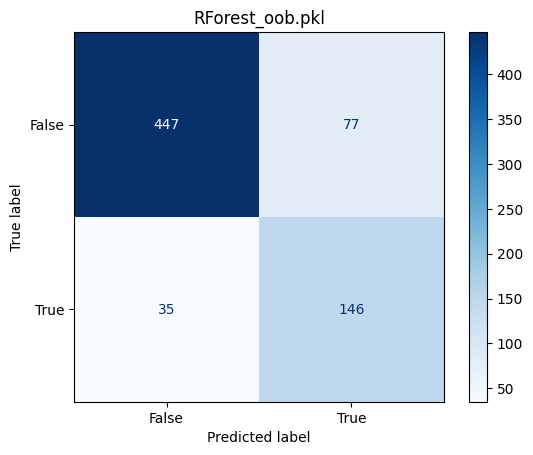

              precision    recall  f1-score   support

       False       0.93      0.85      0.89       524
        True       0.65      0.81      0.72       181

    accuracy                           0.84       705
   macro avg       0.79      0.83      0.81       705
weighted avg       0.86      0.84      0.85       705



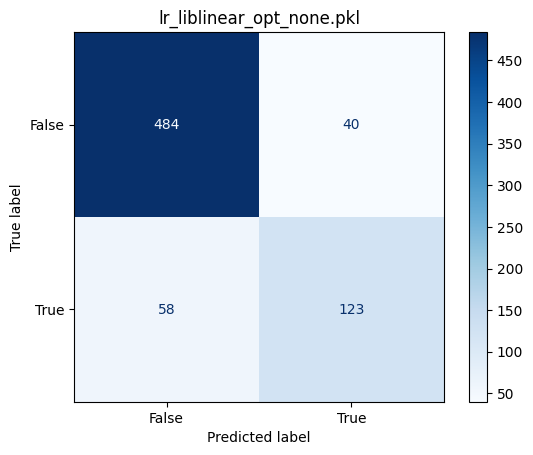

              precision    recall  f1-score   support

       False       0.89      0.92      0.91       524
        True       0.75      0.68      0.72       181

    accuracy                           0.86       705
   macro avg       0.82      0.80      0.81       705
weighted avg       0.86      0.86      0.86       705



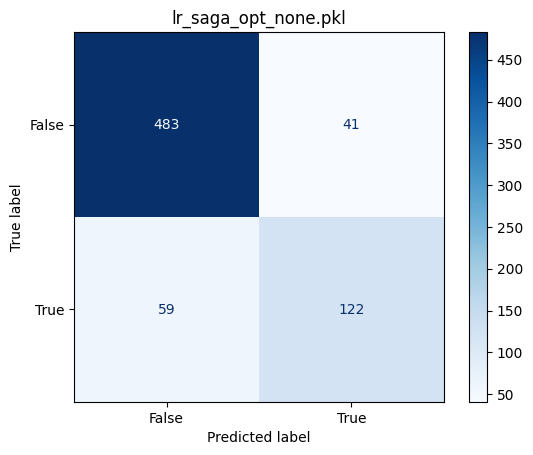

              precision    recall  f1-score   support

       False       0.89      0.92      0.91       524
        True       0.75      0.67      0.71       181

    accuracy                           0.86       705
   macro avg       0.82      0.80      0.81       705
weighted avg       0.85      0.86      0.86       705



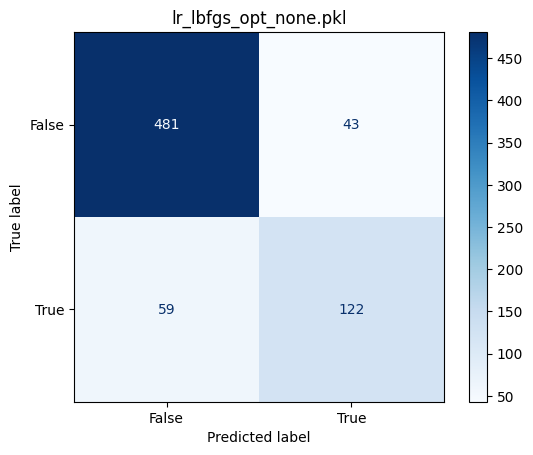

              precision    recall  f1-score   support

       False       0.89      0.92      0.90       524
        True       0.74      0.67      0.71       181

    accuracy                           0.86       705
   macro avg       0.82      0.80      0.80       705
weighted avg       0.85      0.86      0.85       705



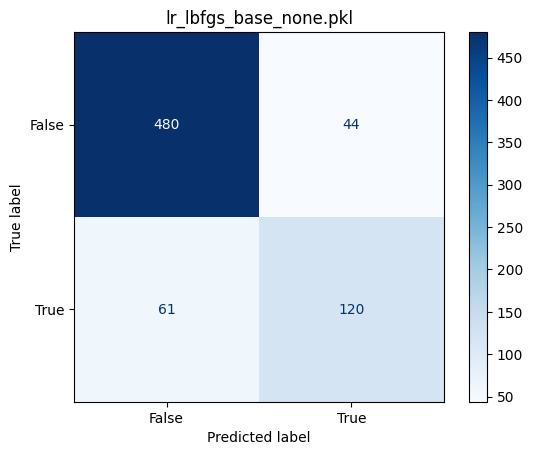

              precision    recall  f1-score   support

       False       0.89      0.92      0.90       524
        True       0.73      0.66      0.70       181

    accuracy                           0.85       705
   macro avg       0.81      0.79      0.80       705
weighted avg       0.85      0.85      0.85       705



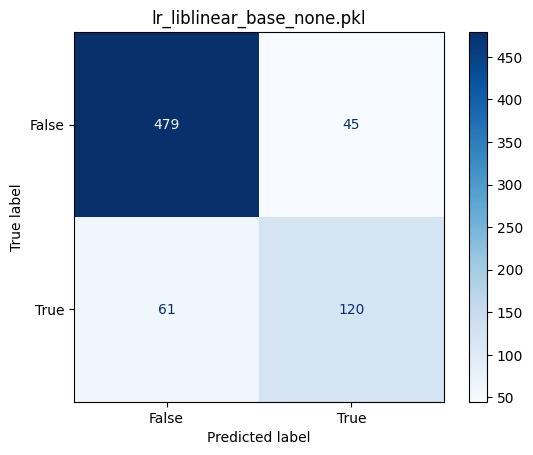

              precision    recall  f1-score   support

       False       0.89      0.91      0.90       524
        True       0.73      0.66      0.69       181

    accuracy                           0.85       705
   macro avg       0.81      0.79      0.80       705
weighted avg       0.85      0.85      0.85       705



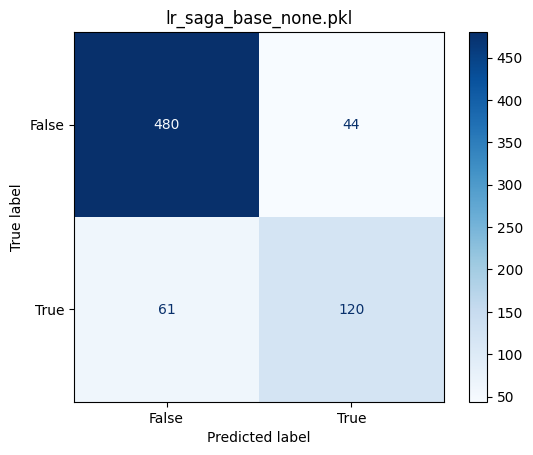

              precision    recall  f1-score   support

       False       0.89      0.92      0.90       524
        True       0.73      0.66      0.70       181

    accuracy                           0.85       705
   macro avg       0.81      0.79      0.80       705
weighted avg       0.85      0.85      0.85       705



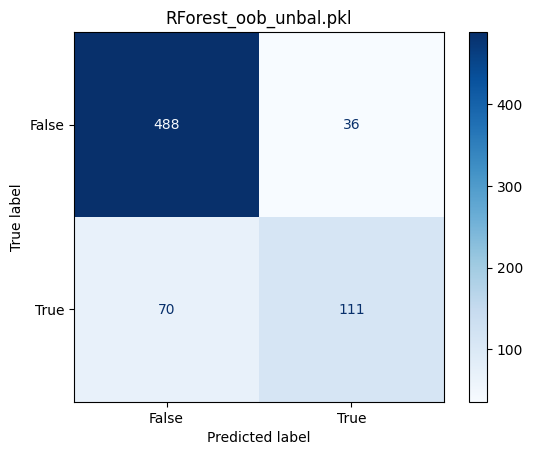

              precision    recall  f1-score   support

       False       0.87      0.93      0.90       524
        True       0.76      0.61      0.68       181

    accuracy                           0.85       705
   macro avg       0.81      0.77      0.79       705
weighted avg       0.84      0.85      0.84       705



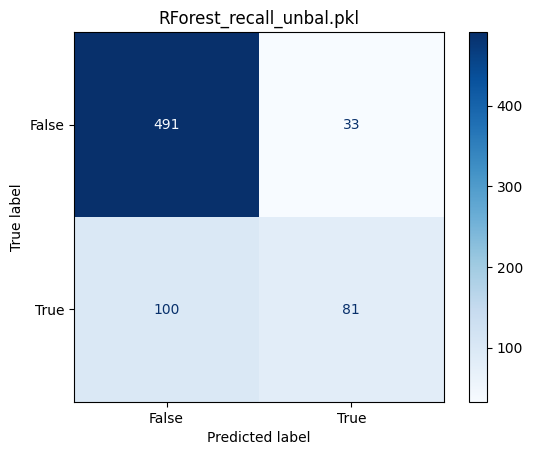

              precision    recall  f1-score   support

       False       0.83      0.94      0.88       524
        True       0.71      0.45      0.55       181

    accuracy                           0.81       705
   macro avg       0.77      0.69      0.71       705
weighted avg       0.80      0.81      0.80       705



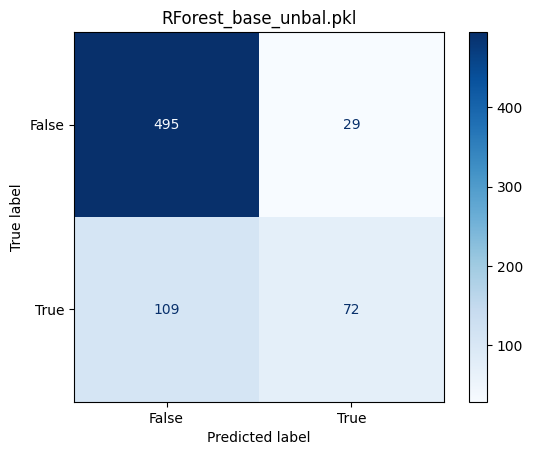

              precision    recall  f1-score   support

       False       0.82      0.94      0.88       524
        True       0.71      0.40      0.51       181

    accuracy                           0.80       705
   macro avg       0.77      0.67      0.69       705
weighted avg       0.79      0.80      0.78       705



In [23]:
for i, row in dr.sort_values(by='recall', ascending=False).iterrows():
    model_name = row['model']

    ruta_completa = os.path.join(MODELS_CLASIFICATION_PATH, model_name)

    # Carga el modelo
    modelo_cargado = joblib.load(ruta_completa)

    # Realizar predicciones
    y_pred = modelo_cargado.predict(Xp)

    # Calcular la matriz de confusión
    cm = confusion_matrix(yp, y_pred)

    # Crear la visualización de la matriz de confusión
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(yp))

    # Mostrar la visualización
    disp.plot(cmap='Blues')

    # Configurar el título
    plt.title(model_name)

    # Mostrar la figura
    plt.show()

    # Mostrar el informe de clasificación
    print(classification_report(yp, y_pred))

#### ROC - Receiver Operating Characteristic

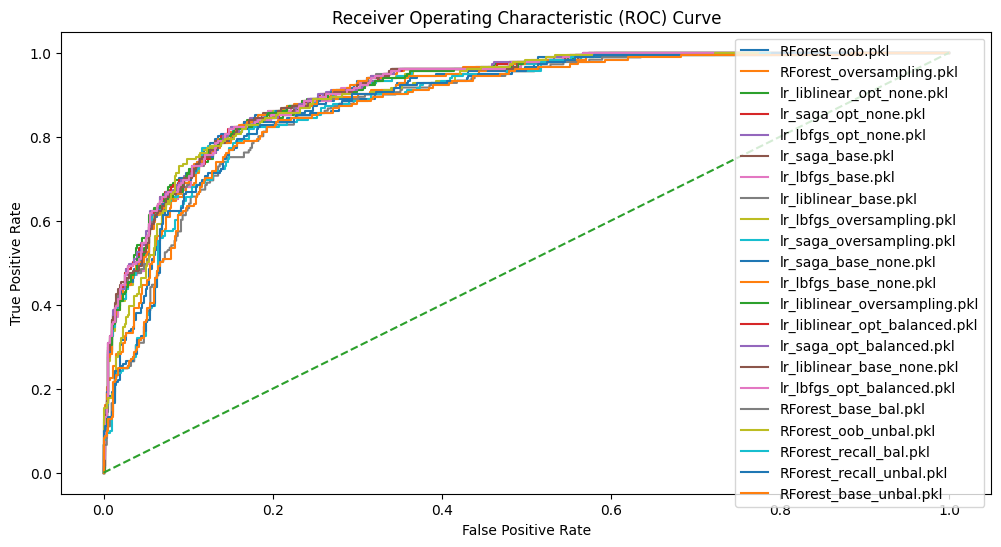

In [24]:
# Crear figura de tamaño 10x6
fig = plt.figure(figsize=(12, 6))


for i, row in dr.sort_values(by='f1_score', ascending=False).iterrows():
    model_name = row['model']

    if archivo_modelo.endswith('.pkl'):
        ruta_completa = os.path.join(MODELS_CLASIFICATION_PATH, model_name)

        # Carga el modelo
        modelo_cargado = joblib.load(ruta_completa)

        # Obtener probabilidades de predicción del modelo
        probs = modelo_cargado.predict_proba(Xp)

        # Seleccionar la columna correspondiente a la probabilidad de clase positiva
        probs = probs[:, 1]

        # Calcular el AUC-ROC
        auc = roc_auc_score(yp, probs*(1))

        # Calcular las tasas de FPR y TPR
        fpr, tpr, _ = roc_curve(yp, probs*(1))

        # Graficar la curva ROC del modelo actual
        plt.plot(fpr, tpr, label=model_name)

        # Mostrar el AUC-ROC y el nombre del modelo
        #print("{:.2f}: {}".format(auc, model_name))


# Graficar la línea diagonal punteada (clasificador aleatorio)
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')  # Etiqueta del eje x
plt.ylabel('True Positive Rate')  # Etiqueta del eje y
plt.title('Receiver Operating Characteristic (ROC) Curve')  # Título del gráfico
plt.legend()  # Mostrar la leyenda de los modelos
plt.show()  # Mostrar el gráfico


#### Referencias


- *scikit-learn:*   
    - https://scikit-learn.org/stable/modules/svm.html
    
    ROC
    - https://stackabuse.com/understanding-roc-curves-with-python/



- *Gráficas con  seaborn:*
    - https://ichi.pro/es/como-utilizar-python-seaborn-para-analisis-de-datos-exploratorios-28897898172180



- *Analítica de grandes datos:*
    - https://jdvelasq.github.io/courses/analitica-de-grandes-datos/index.html